<a href="https://colab.research.google.com/github/PasinBuapan/EN-E-Commerce-Logistics-Pipeline/blob/main/E_Commerce_Logistics_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd

# 1. Create a strict rule for reading weird mixed dates row-by-row
def strict_date_parser(date_str):
    if pd.isna(date_str):
        return pd.NaT
    date_str = str(date_str).strip()
    # If it uses slashes, it's strictly Day/Month/Year
    if '/' in date_str:
        return pd.to_datetime(date_str, format='%d/%m/%Y %H:%M', errors='coerce')
    # Otherwise, it's the standard Year-Month-Day format
    else:
        return pd.to_datetime(date_str, format='%Y-%m-%d %H:%M:%S', errors='coerce')

# 2. THE ULTIMATE PREVENTION: Parse the dates instantly while opening the file!
# This keeps all columns aligned on the exact same rows perfectly.
df_final = pd.read_csv('raw_order_logs.csv')
df_final = df_final.drop_duplicates()

# Apply the strict rule immediately to the columns
for col in ['order_date', 'warehouse_pick_date', 'ship_date', 'delivery_date']:
    df_final[col] = df_final[col].apply(strict_date_parser)

# 3. Clean Carrier Typos automatically
carrier_map = {
    'VelocityAir': 'VelocityAir', 'Velocity Air': 'VelocityAir',
    'SwiftCargo': 'SwiftCargo', 'swift cargo': 'SwiftCargo', 'SwiftCargo LLC': 'SwiftCargo',
    'LogiPost': 'LogiPost', 'logipost': 'LogiPost', 'LogiPost Inc.': 'LogiPost'
}
df_final['carrier'] = df_final['carrier'].map(carrier_map)

# 4. Calculate core metrics safely
df_final['fulfillment_days'] = (df_final['warehouse_pick_date'] - df_final['order_date']).dt.days
df_final['shipping_days'] = (df_final['delivery_date'] - df_final['ship_date']).dt.days
df_final['total_delivery_days'] = (df_final['delivery_date'] - df_final['order_date']).dt.days

print("--- 🎯 System Sanitized & All Rows Perfectly Aligned! ---")
print(df_final[['order_id', 'order_date', 'warehouse_pick_date', 'fulfillment_days', 'total_delivery_days']].head())

--- 🎯 System Sanitized & All Rows Perfectly Aligned! ---
   order_id          order_date warehouse_pick_date  fulfillment_days  total_delivery_days
0     10000 2026-03-11 08:00:00                 NaT               NaN                  NaN
1     10001 2026-03-18 08:00:00                 NaT               NaN                  NaN
2     10002 2026-01-04 05:00:00                 NaT               NaN                  NaN
3     10003 2026-01-23 18:00:00                 NaT               NaN                  NaN
4     10004 2026-03-26 14:00:00                 NaT               NaN                  NaN


In [18]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Set random seed for reproducibility
np.random.seed(42)
num_orders = 800

# 1. Generate base IDs
order_ids = [10000 + i for i in range(num_orders)]
customer_ids = [np.random.randint(50000, 55000) for _ in range(num_orders)]

# 2. Generate categories and items
categories = ['Smart Lighting', 'Security', 'Audio', 'Power']
cat_choices = np.random.choice(categories, num_orders, p=[0.3, 0.4, 0.2, 0.1])
costs = {'Smart Lighting': 45.0, 'Security': 120.0, 'Audio': 85.0, 'Power': 30.0}
item_costs = [costs[cat] for cat in cat_choices]

# 3. Generate Timeline Metrics (Deliberately messy dates)
start_date = datetime(2026, 1, 1)
order_dates = []
pick_dates = []
ship_dates = []
delivery_dates = []
carriers = []
statuses = []

carrier_options = ['LogiPost', 'SwiftCargo', 'VelocityAir']

for i in range(num_orders):
    # Order Date
    days_offset = np.random.randint(0, 90)
    hours_offset = np.random.randint(0, 24)
    o_date = start_date + timedelta(days=days_offset, hours=hours_offset)
    order_dates.append(o_date)

    # Process Status & Logic
    rand = np.random.rand()
    if rand < 0.05:  # 5% Canceled early
        pick_dates.append(pd.NaT)
        ship_dates.append(pd.NaT)
        delivery_dates.append(pd.NaT)
        carriers.append(np.nan)
        statuses.append('Canceled')
    elif rand < 0.20:  # 15% Delayed severely at warehouse stage
        p_date = o_date + timedelta(days=np.random.randint(4, 8))
        s_date = p_date + timedelta(days=np.random.randint(1, 3))
        d_date = s_date + timedelta(days=np.random.randint(3, 6))
        pick_dates.append(p_date)
        ship_dates.append(s_date)
        delivery_dates.append(d_date)
        carriers.append(np.random.choice(carrier_options))
        statuses.append('Delayed')
    else:  # Standard delivery pipeline
        p_date = o_date + timedelta(days=np.random.randint(1, 3))
        s_date = p_date + timedelta(days=1)
        # VelocityAir is fast, SwiftCargo is average, LogiPost has delays
        carrier = np.random.choice(carrier_options, p=[0.3, 0.4, 0.3])
        carriers.append(carrier)

        if carrier == 'VelocityAir':
            d_date = s_date + timedelta(days=np.random.randint(1, 3))
        elif carrier == 'SwiftCargo':
            d_date = s_date + timedelta(days=np.random.randint(2, 5))
        else:
            d_date = s_date + timedelta(days=np.random.randint(4, 9))

        pick_dates.append(p_date)
        ship_dates.append(s_date)
        delivery_dates.append(d_date)
        statuses.append('Delivered')

# 4. Format Dates with Inconsistent Strings
date_strings = []
for d in order_dates:
    if np.random.rand() < 0.15:
        date_strings.append(d.strftime('%d/%m/%Y %H:%M')) # DD/MM/YYYY
    else:
        date_strings.append(d.strftime('%Y-%m-%d %H:%M:%S')) # YYYY-MM-DD

# 5. Build Initial DataFrame
df = pd.DataFrame({
    'order_id': order_ids,
    'customer_id': customer_ids,
    'order_date': date_strings,
    'warehouse_pick_date': [d.strftime('%Y-%m-%d') if not pd.isna(d) else np.nan for d in pick_dates],
    'ship_date': [d.strftime('%Y-%m-%d') if not pd.isna(d) else np.nan for d in ship_dates],
    'delivery_date': [d.strftime('%Y-%m-%d') if not pd.isna(d) else np.nan for d in delivery_dates],
    'carrier': carriers,
    'order_status': statuses,
    'product_category': cat_choices,
    'item_cost': item_costs
})

# 6. Introduce "Dirty Data" anomalies intentionally
# Introduce messy typos in carrier names
df['carrier'] = df['carrier'].replace({
    'LogiPost': np.random.choice(['LogiPost', 'logipost', 'LogiPost Inc.'], num_orders, p=[0.7, 0.15, 0.15]),
    'SwiftCargo': np.random.choice(['SwiftCargo', 'swift cargo', 'SwiftCargo LLC'], num_orders, p=[0.7, 0.15, 0.15]),
    'VelocityAir': np.random.choice(['VelocityAir', 'Velocity Air'], num_orders, p=[0.8, 0.2])
})

# Inject pure duplicates (15 identical rows duplicated)
dup_indices = np.random.choice(df.index, 15, replace=False)
df_dups = df.iloc[dup_indices]
df = pd.concat([df, df_dups], ignore_index=True)

# Save to local virtual drive inside Colab
df.to_csv('raw_order_logs.csv', index=False)
print("📦 Data Generation Successful! 'raw_order_logs.csv' is generated and saved.")

📦 Data Generation Successful! 'raw_order_logs.csv' is generated and saved.


In [19]:
# Load the generated raw data
df_raw = pd.read_csv('raw_order_logs.csv')

print("--- 1. Dataset Shape ---")
print(f"Total Rows: {df_raw.shape[0]}, Total Columns: {df_raw.shape[1]}\n")

print("--- 2. Missing Values (Nulls) Per Column ---")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0], "\n")

print("--- 3. Total Duplicate Rows Detected ---")
print(df_raw.duplicated().sum(), "\n")

print("--- 4. Unique Values in 'carrier' (Checking for Typos) ---")
print(df_raw['carrier'].unique(), "\n")

print("--- 5. First 5 Rows Sample ---")
df_raw.head()

--- 1. Dataset Shape ---
Total Rows: 815, Total Columns: 10

--- 2. Missing Values (Nulls) Per Column ---
warehouse_pick_date    52
ship_date              52
delivery_date          52
carrier                52
dtype: int64 

--- 3. Total Duplicate Rows Detected ---
15 

--- 4. Unique Values in 'carrier' (Checking for Typos) ---
['VelocityAir' 'SwiftCargo LLC' 'LogiPost' 'SwiftCargo' 'swift cargo' nan
 'LogiPost Inc.' 'logipost' 'Velocity Air'] 

--- 5. First 5 Rows Sample ---


,order_id,customer_id,order_date,warehouse_pick_date,ship_date,delivery_date,carrier,order_status,product_category,item_cost
0,10000,50860,11/03/2026 08:00,2026-03-12,2026-03-13,2026-03-14,VelocityAir,Delivered,Smart Lighting,45.0
1,10001,53772,2026-03-18 08:00:00,2026-03-23,2026-03-24,2026-03-28,SwiftCargo LLC,Delayed,Smart Lighting,45.0
2,10002,53092,2026-01-04 05:00:00,2026-01-06,2026-01-07,2026-01-08,VelocityAir,Delivered,Smart Lighting,45.0
3,10003,50466,2026-01-23 18:00:00,2026-01-24,2026-01-25,2026-01-29,LogiPost,Delivered,Smart Lighting,45.0
4,10004,54426,2026-03-26 14:00:00,2026-03-28,2026-03-29,2026-03-31,SwiftCargo,Delivered,Smart Lighting,45.0


In [20]:
# 1. Create a fresh copy of the raw data to clean
df_clean = df_raw.copy()

# Fix Issue 1: Drop pure duplicate rows
df_clean = df_clean.drop_duplicates()

# Fix Issue 2: Standardize Carrier Names using Mapping
carrier_map = {
    'VelocityAir': 'VelocityAir', 'Velocity Air': 'VelocityAir',
    'SwiftCargo': 'SwiftCargo', 'swift cargo': 'SwiftCargo', 'SwiftCargo LLC': 'SwiftCargo',
    'LogiPost': 'LogiPost', 'logipost': 'LogiPost', 'LogiPost Inc.': 'LogiPost'
}
df_clean['carrier'] = df_clean['carrier'].map(carrier_map)

# Fix Issue 3: Standardize Date Formats
# 'errors="coerce"' turns completely unparseable text into Nulls safely, 'format="mixed"' auto-detects different styles
date_cols = ['order_date', 'warehouse_pick_date', 'ship_date', 'delivery_date']
for col in date_cols:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce', format='mixed')

print("--- ✅ Initial Cleaning Complete! ---")
print(f"New Row Count (Should be 800): {df_clean.shape[0]}")
print(f"Cleaned Carrier Names: {df_clean['carrier'].dropna().unique()}\n")

print("--- 🔍 Checking the Missing Values Logic ---")
# Let's see if the 52 missing values match canceled orders exactly
canceled_orders = df_clean[df_clean['order_status'] == 'Canceled']
print(f"Total Canceled Orders: {len(canceled_orders)}")
print(f"Missing values in carrier for canceled orders: {canceled_orders['carrier'].isnull().sum()}")

--- ✅ Initial Cleaning Complete! ---
New Row Count (Should be 800): 800
Cleaned Carrier Names: ['VelocityAir' 'SwiftCargo' 'LogiPost']

--- 🔍 Checking the Missing Values Logic ---
Total Canceled Orders: 51
Missing values in carrier for canceled orders: 51


In [21]:
import pandas as pd

# 1. Reset completely from the raw file
df_final = pd.read_csv('raw_order_logs.csv')
df_final = df_final.drop_duplicates()

# 2. Clean Carrier Names
carrier_map = {
    'VelocityAir': 'VelocityAir', 'Velocity Air': 'VelocityAir',
    'SwiftCargo': 'SwiftCargo', 'swift cargo': 'SwiftCargo', 'SwiftCargo LLC': 'SwiftCargo',
    'LogiPost': 'LogiPost', 'logipost': 'LogiPost', 'LogiPost Inc.': 'LogiPost'
}
df_final['carrier'] = df_final['carrier'].map(carrier_map)

# 3. FIX THE ERROR: Explicitly check the string format for each row
def parse_mixed_dates(date_str):
    if pd.isna(date_str):
        return pd.NaT
    date_str = str(date_str).strip()

    # If the text has slashes, it is strictly DD/MM/YYYY
    if '/' in date_str:
        return pd.to_datetime(date_str, format='%d/%m/%Y %H:%M', errors='coerce')
    # Otherwise, it is standard YYYY-MM-DD
    else:
        return pd.to_datetime(date_str, format='%Y-%m-%d %H:%M:%S', errors='coerce')

# Apply our rule to the order_date column
df_final['order_date'] = df_final['order_date'].apply(parse_mixed_dates)

# Standardize the other warehouse tracking date columns safely
df_final['warehouse_pick_date'] = pd.to_datetime(df_final['warehouse_pick_date'], errors='coerce')
df_final['ship_date'] = pd.to_datetime(df_final['ship_date'], errors='coerce')
df_final['delivery_date'] = pd.to_datetime(df_final['delivery_date'], errors='coerce')

# 4. Calculate core logistics metrics
df_final['fulfillment_days'] = (df_final['warehouse_pick_date'] - df_final['order_date']).dt.days
df_final['shipping_days'] = (df_final['delivery_date'] - df_final['ship_date']).dt.days
df_final['total_delivery_days'] = (df_final['delivery_date'] - df_final['order_date']).dt.days

print("--- 🎯 Data Pipeline Verification Complete ---")
print(df_final[['order_id', 'order_date', 'warehouse_pick_date', 'fulfillment_days', 'shipping_days', 'total_delivery_days']].head())

print("\n--- 🚛 Cleaned Carrier Shipping Performance (Averages) ---")
print(df_final[df_final['order_status'] == 'Delivered'].groupby('carrier')['shipping_days'].mean())

# Save the perfectly clean data
df_final.to_csv('cleaned_order_logs.csv', index=False)

--- 🎯 Data Pipeline Verification Complete ---
   order_id          order_date warehouse_pick_date  fulfillment_days  shipping_days  total_delivery_days
0     10000 2026-03-11 08:00:00          2026-03-12               0.0            1.0                  2.0
1     10001 2026-03-18 08:00:00          2026-03-23               4.0            4.0                  9.0
2     10002 2026-01-04 05:00:00          2026-01-06               1.0            1.0                  3.0
3     10003 2026-01-23 18:00:00          2026-01-24               0.0            4.0                  5.0
4     10004 2026-03-26 14:00:00          2026-03-28               1.0            2.0                  4.0

--- 🚛 Cleaned Carrier Shipping Performance (Averages) ---
carrier
LogiPost       6.194595
SwiftCargo     3.038610
VelocityAir    1.529730
Name: shipping_days, dtype: float64


In [22]:
print("--- 💵 1. Total Delayed Backlog Value ---")
# Find out how much revenue is trapped in 'Delayed' or 'Warehouse Delay' status
delayed_revenue = df_final[df_final['order_status'] == 'Delayed']['item_cost'].sum()
print(f"Total Revenue Currently Delayed in Pipeline: ${delayed_revenue:,.2f}\n")

print("--- 📦 2. Order Distribution by Product Category ---")
print(df_final['product_category'].value_counts(normalize=True) * 100)

print("\n--- ⏳ 3. Average Warehouse Fulfillment Time ---")
avg_fulfillment = df_final['fulfillment_days'].mean()
print(f"Average days spent in warehouse packing stage: {avg_fulfillment:.1f} days")

--- 💵 1. Total Delayed Backlog Value ---
Total Revenue Currently Delayed in Pipeline: $9,400.00

--- 📦 2. Order Distribution by Product Category ---
product_category
Security          38.125
Smart Lighting    31.750
Audio             19.875
Power             10.250
Name: proportion, dtype: float64

--- ⏳ 3. Average Warehouse Fulfillment Time ---
Average days spent in warehouse packing stage: 1.2 days


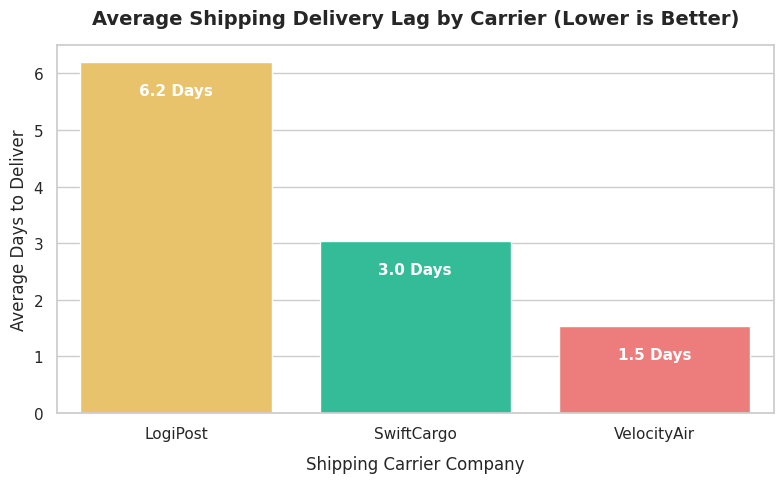

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Create a bar chart of shipping performance
colors = ['#ff6b6b', '#feca57', '#1dd1a1']
ax = sns.barplot(
    x='carrier',
    y='shipping_days',
    hue='carrier',
    data=df_final[df_final['order_status'] == 'Delivered'],
    errorbar=None,
    palette=colors,
    order=['LogiPost', 'SwiftCargo', 'VelocityAir'],
    legend=False
)

# Add labels and a title
plt.title('Average Shipping Delivery Lag by Carrier (Lower is Better)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Shipping Carrier Company', fontsize=12, labelpad=10)
plt.ylabel('Average Days to Deliver', fontsize=12)

# Add the actual number labels on top of the bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f} Days", (p.get_x() + p.get_width() / 2., p.get_height() - 0.5),
                ha='center', va='center', color='white', fontweight='bold', size=11)

plt.tight_layout()
plt.show()

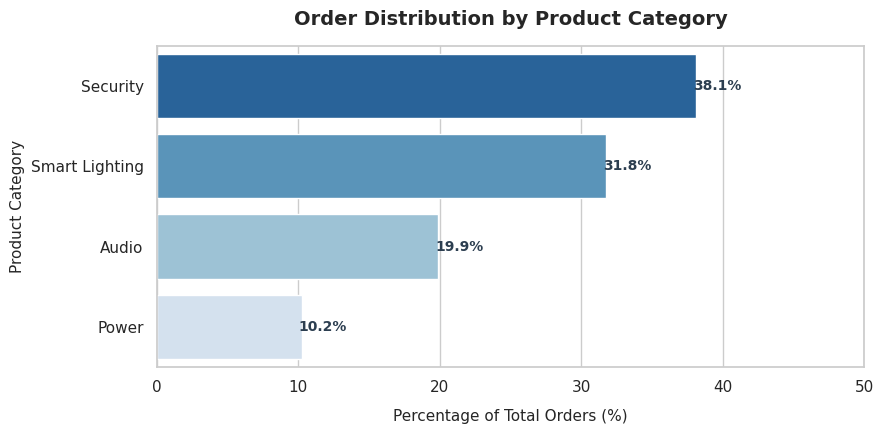

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate product category percentages
category_data = df_final['product_category'].value_counts(normalize=True).reset_index()
category_data.columns = ['product_category', 'percentage']
category_data['percentage'] = category_data['percentage'] * 100

# Set up the visual canvas
plt.figure(figsize=(9, 4.5))
sns.set_theme(style="whitegrid")

# Create a clean horizontal bar chart
ax = sns.barplot(
    x='percentage',
    y='product_category',
    hue='product_category',
    data=category_data,
    palette='Blues_r',
    legend=False
)

# Add titles and clean up labels
plt.title('Order Distribution by Product Category', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Percentage of Total Orders (%)', fontsize=11, labelpad=10)
plt.ylabel('Product Category', fontsize=11)
plt.xlim(0, 50)

# Add clear data labels to the end of each horizontal bar
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f"{width:.1f}%", (width + 1.5, p.get_y() + p.get_height() / 2.),
                    ha='center', va='center', fontsize=10, fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.show()